In [1]:
!pip install tensorflow

In [2]:
import os
import random
import pandas as pd
import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt
from PIL import Image

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [3]:
os.makedirs("Dataset/images/train", exist_ok=True)
os.makedirs("Dataset/images/val", exist_ok=True)

print("Estrutura criada")

Estrutura criada


In [29]:
import shutil

random.seed(42)

all_images = [f for f in os.listdir() if f.endswith(".jpg")]

random.shuffle(all_images)

train_split = int(0.66*len(all_images))

train_files = all_images[:train_split]
val_files = all_images[train_split:]

for f in train_files:
    shutil.copy(f,"Dataset/images/train")

for f in val_files:
    shutil.copy(f,"Dataset/images/val")

print("Train:",len(train_files))
print("Val:",len(val_files))

Train: 11
Val: 7


In [30]:
random.seed(42)

def get_class(filename):

    f = filename.lower()

    if f.startswith("sandalia"):
        return "sandalia"

    if f.startswith("tenis"):
        return "tenis"

    if f.startswith("salto"):
        return "outros"

    return "outros"


class_to_id = {
    "sandalia":0,
    "tenis":1,
    "outros":2
}


texts = {

"sandalia":[
"Foto de uma sandalia",
"Imagem de sandalia",
"Uma sandalia sobre o piso",
"Sandalia fotografada",
"Objeto sandalia"
],

"tenis":[
"Foto de um tenis",
"Imagem de tenis",
"Um tenis sobre o piso",
"Tenis fotografado",
"Objeto tenis"
],

"outros":[
"Outro tipo de calcado",
"Calcado diferente",
"Calcado que nao e tenis nem sandalia",
"Objeto diferente",
"Outro tipo de sapato"
]

}

In [31]:
df = pd.DataFrame(rows,columns=["image","text","label","split"])

print(df.head())
print("Total pares:",len(df))

TRAIN_DIR = "Dataset/images/train"
VAL_DIR = "Dataset/images/val"

def generate_pairs(folder,split):

    for file in os.listdir(folder):

        label_name = get_class(file)
        label_id = class_to_id[label_name]

        image_path = os.path.join(folder,file)

        for text in texts[label_name]:

            rows.append([
                image_path,
                text,
                label_id,
                split
            ])


generate_pairs(TRAIN_DIR,"train")
generate_pairs(VAL_DIR,"val")

df = pd.DataFrame(rows,columns=[
"image",
"text",
"label",
"split"
])


print("Total pares:",len(df))

df.head()

                                  image                       text  label  \
0  Dataset/images/train/sandalia2_1.jpg       Foto de uma sandalia      0   
1  Dataset/images/train/sandalia2_1.jpg         Imagem de sandalia      0   
2  Dataset/images/train/sandalia2_1.jpg  Uma sandalia sobre o piso      0   
3  Dataset/images/train/sandalia2_1.jpg       Sandalia fotografada      0   
4  Dataset/images/train/sandalia2_1.jpg            Objeto sandalia      0   

   split  
0  train  
1  train  
2  train  
3  train  
4  train  
Total pares: 90
Total pares: 180


,image,text,label,split
0,Dataset/images/train/sandalia2_1.jpg,Foto de uma sandalia,0,train
1,Dataset/images/train/sandalia2_1.jpg,Imagem de sandalia,0,train
2,Dataset/images/train/sandalia2_1.jpg,Uma sandalia sobre o piso,0,train
3,Dataset/images/train/sandalia2_1.jpg,Sandalia fotografada,0,train
4,Dataset/images/train/sandalia2_1.jpg,Objeto sandalia,0,train


In [32]:
train_df = df[df.split=="train"]
val_df   = df[df.split=="val"]

print("Train pares:",len(train_df))
print("Val pares:",len(val_df))

Train pares: 110
Val pares: 70


In [33]:
max_tokens = 1000
sequence_length = 20

vectorizer = tf.keras.layers.TextVectorization(

max_tokens=max_tokens,
output_mode="int",
output_sequence_length=sequence_length

)

vectorizer.adapt(train_df.text.values)

print("Vocabulário criado")

Vocabulário criado


In [34]:
IMG_SIZE = (128,128)

def load_image_fixed(path):

    img = tf.io.read_file(path)

    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, IMG_SIZE)

    img = tf.cast(img, tf.float32) / 255.0

    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])

    return img

In [44]:
def make_dataset(dataframe):

    paths = dataframe.image.values
    texts = dataframe.text.values
    labels = dataframe.label.values

    dataset = tf.data.Dataset.from_tensor_slices((paths,texts,labels))

    def process(path,text,label):

        img = load_image_fixed(path)

        txt = vectorizer(text)

        return {

            "image":img,
            "text":txt

        },label


    dataset = dataset.map(process)

    dataset = dataset.batch(8)

    return dataset


train_ds_fixed = make_dataset(train_df)
val_ds_fixed   = make_dataset(val_df)

print("Datasets criados")

Datasets criados


In [45]:
model = tf.keras.Model(
    inputs=[image_input,text_input],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 20)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 20, 128)   │    128,000 │ text[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 1280)      │  2,257,984 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ embedding_2[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │    163,968 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 256)       │          0 │ dense_8[0][0],    │
│ (Concatenate)       │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     32,896 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 3)         │        387 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,599,747 (9.92 MB)

 Trainable params: 341,763 (1.30 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [46]:
# Modelo Multimodal
num_classes = 3


image_input = tf.keras.Input(shape=(128,128,3),name="image")

base_model = tf.keras.applications.MobileNetV2(

weights="imagenet",
include_top=False,
pooling="avg"

)

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable=False

image_features = base_model(image_input)

image_features = tf.keras.layers.Dense(128,activation="relu")(image_features)



text_input = tf.keras.Input(shape=(sequence_length,),name="text")

x = tf.keras.layers.Embedding(max_tokens,128)(text_input)

x = tf.keras.layers.GlobalAveragePooling1D()(x)

text_features = tf.keras.layers.Dense(128,activation="relu")(x)



combined = tf.keras.layers.Concatenate()([image_features,text_features])

combined = tf.keras.layers.Dense(128,activation="relu")(combined)

output = tf.keras.layers.Dense(num_classes,activation="softmax")(combined)


model = tf.keras.Model(

inputs={
"image":image_input,
"text":text_input

},

outputs=output
)


model.compile(

optimizer="adam",

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)


model.summary()

/tmp/ipython-input-344/372703372.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 20)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 20, 128)   │    128,000 │ text[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 1280)      │  2,257,984 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ embedding_3[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │    163,968 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256)       │          0 │ dense_12[0][0],   │
│ (Concatenate)       │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     32,896 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 3)         │        387 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,599,747 (9.92 MB)

 Trainable params: 1,394,243 (5.32 MB)

 Non-trainable params: 1,205,504 (4.60 MB)

In [47]:
from PIL import Image
import os

all_images = train_df.image.tolist() + val_df.image.tolist()

for img_path in all_images:
    try:
        img = Image.open(img_path)
        img.verify()
    except:
        print("Imagem inválida:", img_path)

In [48]:
def convert_to_jpg(path):
    try:
        img = Image.open(path).convert("RGB")
        img.save(path,"JPEG")
    except:
        print("Erro ao converter:",path)

for img_path in all_images:
    convert_to_jpg(img_path)

print("Conversão concluída")

Conversão concluída


In [49]:
history = model.fit(
    train_ds_fixed,
    validation_data=val_ds_fixed,
    epochs=20
)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5148 - loss: 1.1207 - val_accuracy: 0.5714 - val_loss: 1.1343
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 697ms/step - accuracy: 1.0000 - loss: 0.1351 - val_accuracy: 0.7143 - val_loss: 0.7389
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 748ms/step - accuracy: 1.0000 - loss: 0.0111 - val_accuracy: 0.7143 - val_loss: 0.6818
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 740ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.7143 - val_loss: 0.6153
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 700ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.7143 - val_loss: 0.5146
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 836ms/step - accuracy: 1.0000 - loss: 7.5084e-04 - val_accuracy: 0.7143 - val_loss: 0.4035
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 699ms/step - accuracy: 1.0000 - loss: 5.5459e-04 - val_accuracy: 0.7143 - val_loss: 0.3095
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 742ms/step - accuracy: 1.0000 - loss: 4.3665e-04 -

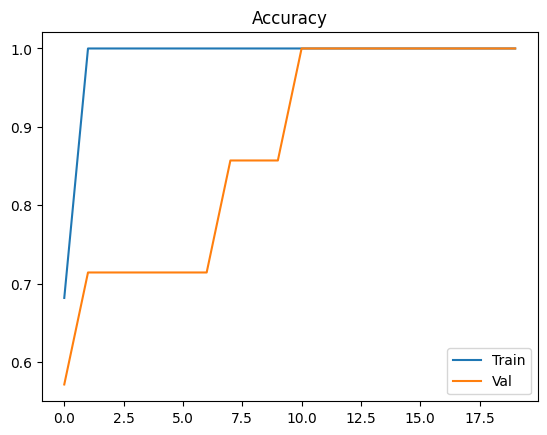

In [50]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.legend(['Train','Val'])
plt.show()

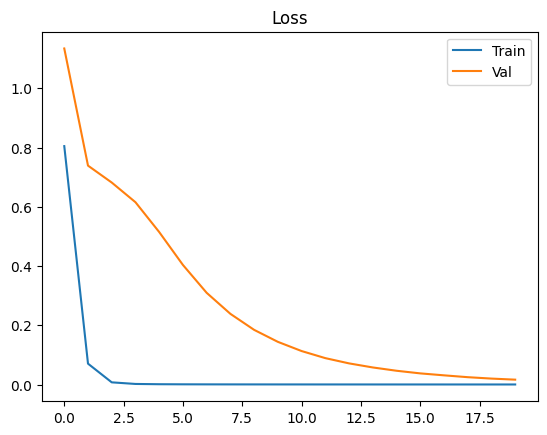

In [51]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.legend(['Train','Val'])
plt.show()

In [52]:
test_img = load_image_fixed("/content/tenis1_1.jpg")

test_txt = vectorizer(["foto de um tenis esportivo"])

pred = model.predict({
    "image":tf.expand_dims(test_img,0),
    "text":test_txt
})

print(pred)
print("Classe prevista:",np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[3.0333533e-15 1.0000000e+00 2.3801200e-12]]
Classe prevista: 1
